<a href="https://colab.research.google.com/github/OugoMartin/TravelTide/blob/main/TravelTide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dataset Acquisition**

In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n_samples = 1000
data = {
    'customer_id': range(1, n_samples + 1),
    'home_city': np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'], n_samples),
    'signup_date': pd.to_datetime(np.random.choice(pd.date_range('2020-01-01', '2023-01-01', freq='D'), n_samples)),
    'flight_bookings': np.random.poisson(3, n_samples),
    'hotel_bookings': np.random.poisson(2, n_samples),
    'total_spent': np.random.normal(1500, 500, n_samples),
    'avg_bags_checked': np.random.normal(1.5, 0.5, n_samples),
    'cancellations': np.random.binomial(1, 0.1, n_samples)
}

df = pd.DataFrame(data)

# Save to CSV
df.to_csv('Final_TravelTide query.xlsx', index=False)

**Exploratory Data Analysis (EDA)**

**Missing Values**: Impute missing values using the median for numerical columns and mode for categorical columns.

In [2]:
df['total_spent'].fillna(df['total_spent'].median(), inplace=True)
df['home_city'].fillna(df['home_city'].mode()[0], inplace=True)


/tmp/ipython-input-4099864877.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_spent'].fillna(df['total_spent'].median(), inplace=True)
/tmp/ipython-input-4099864877.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

**Outliers**: Detect and handle outliers using the Interquartile Range (IQR) method.

In [3]:
Q1 = df['total_spent'].quantile(0.25)
Q3 = df['total_spent'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['total_spent'] >= Q1 - 1.5 * IQR) & (df['total_spent'] <= Q3 + 1.5 * IQR)]


**Normalization/Scaling**: Apply *StandardScaler* to numerical features.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['total_spent', 'avg_bags_checked']] = scaler.fit_transform(df[['total_spent', 'avg_bags_checked']])


**Feature Engineering**



**Booking Ratio**: Create a new feature representing the ratio of flight bookings to hotel bookings.

In [5]:
df['flight_to_hotel_ratio'] = df['flight_bookings'] / (df['hotel_bookings'] + 1)


**Loyalty Index**: Develop a composite index based on spending and cancellations.

In [6]:
df['loyalty_index'] = df['total_spent'] - (df['cancellations'] * 100)


In [7]:
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('Final_TravelTide query.xlsx')

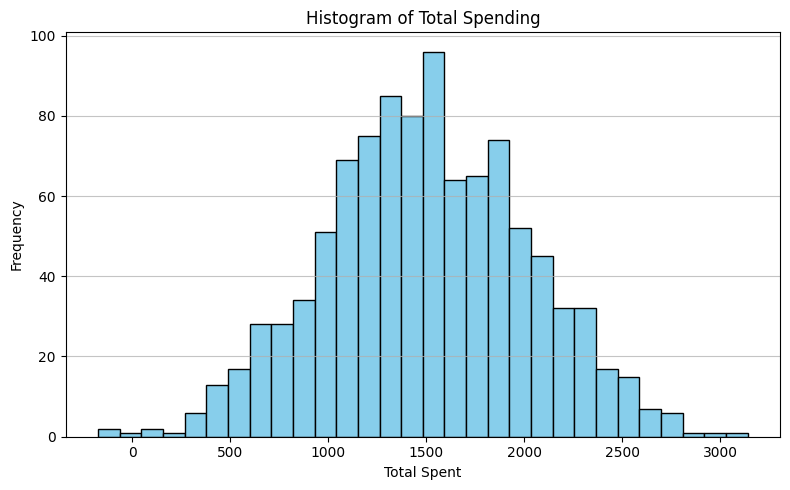

In [9]:
# Histogram of total_spent
# ----------------------------
plt.figure(figsize=(8, 5))
plt.hist(df['total_spent'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Total Spending')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

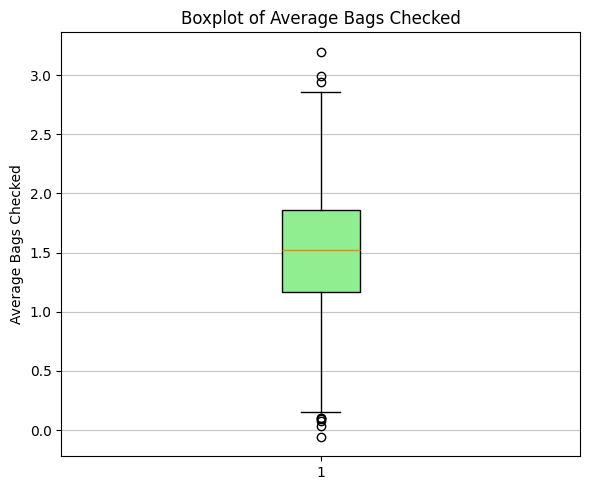

In [10]:
# Boxplot of avg_bags_checked
# ----------------------------
plt.figure(figsize=(6, 5))
plt.boxplot(df['avg_bags_checked'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('Boxplot of Average Bags Checked')
plt.ylabel('Average Bags Checked')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

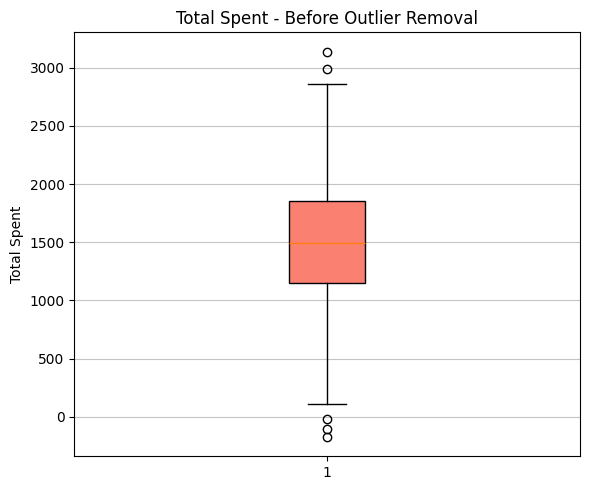

In [11]:
# Boxplot of total_spent before and after outlier removal
# ----------------------------

# Before outlier removal
plt.figure(figsize=(6, 5))
plt.boxplot(df['total_spent'], patch_artist=True, boxprops=dict(facecolor='salmon'))
plt.title('Total Spent - Before Outlier Removal')
plt.ylabel('Total Spent')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [12]:
# Remove outliers using IQR
Q1 = df['total_spent'].quantile(0.25)
Q3 = df['total_spent'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['total_spent'] >= Q1 - 1.5*IQR) & (df['total_spent'] <= Q3 + 1.5*IQR)]

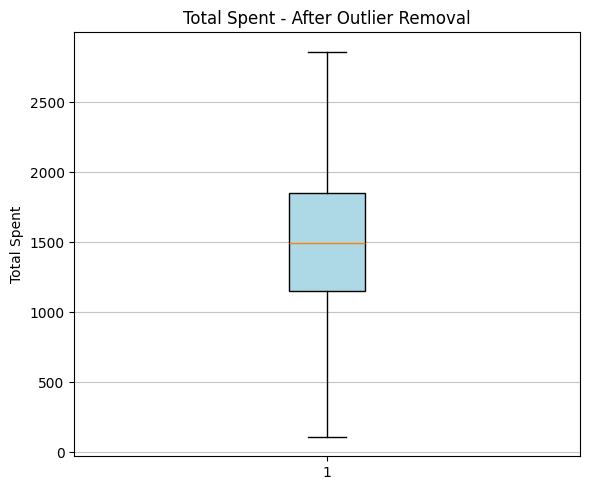

In [13]:
# After outlier removal
plt.figure(figsize=(6, 5))
plt.boxplot(df_clean['total_spent'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Total Spent - After Outlier Removal')
plt.ylabel('Total Spent')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [14]:
# Bar chart of average loyalty index by city
# ----------------------------

# Create loyalty index: total_spent - (cancellations * 100)
df_clean['loyalty_index'] = df_clean['total_spent'] - (df_clean['cancellations'] * 100)

/tmp/ipython-input-3267463726.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['loyalty_index'] = df_clean['total_spent'] - (df_clean['cancellations'] * 100)


In [15]:
# Calculate average loyalty index per city
loyalty_by_city = df_clean.groupby('home_city')['loyalty_index'].mean().sort_values()

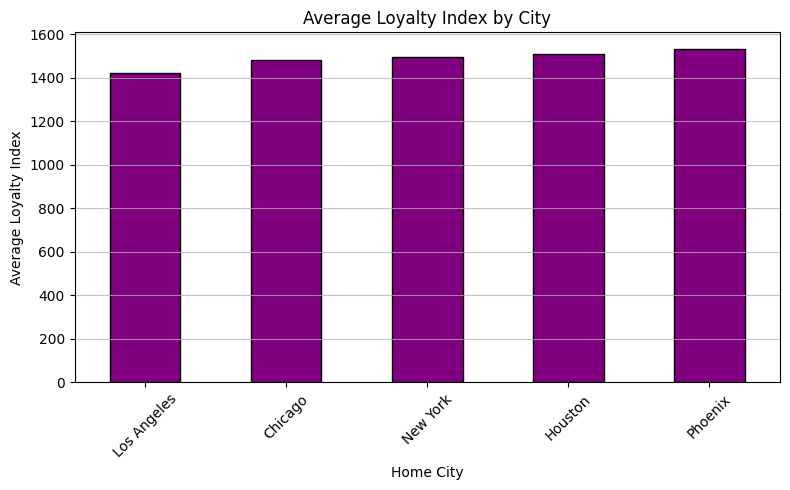

In [16]:
# Plot bar chart
plt.figure(figsize=(8, 5))
loyalty_by_city.plot(kind='bar', color='purple', edgecolor='black')
plt.title('Average Loyalty Index by City')
plt.xlabel('Home City')
plt.ylabel('Average Loyalty Index')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()